## Project Goal

Perform Exploratory Data Analysis (EDA) to understand:

Netflix content distribution

Popular genres

Movies vs TV shows

Content growth over time

## Data set Overview
Load dataset

Check shape

List columns

Check data types

Check missing values

Check duplicates

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [9]:
# drop null values 

df.dropna(subset=['date_added', 'rating', 'duration'] ,inplace=True)

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

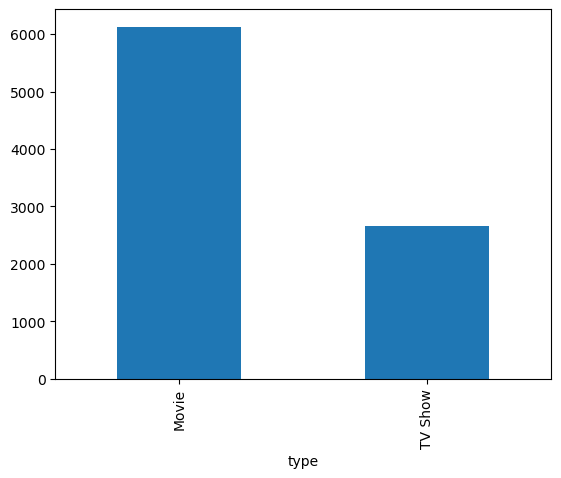

In [12]:
#How many Movies vs TV Shows are there?

df['type'].value_counts().plot(kind='bar')
plt.show()

## Content Type Analysis


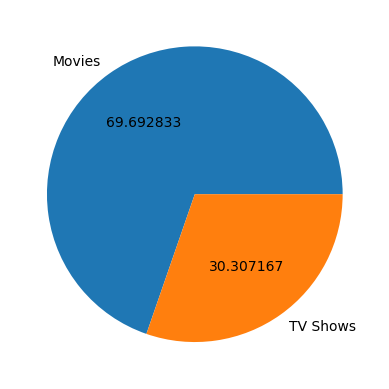

In [13]:
#What percentage are movies?

plt.pie(df['type'].value_counts(), labels=['Movies','TV Shows'],autopct='%f')
plt.show()

# Release Year Analysis

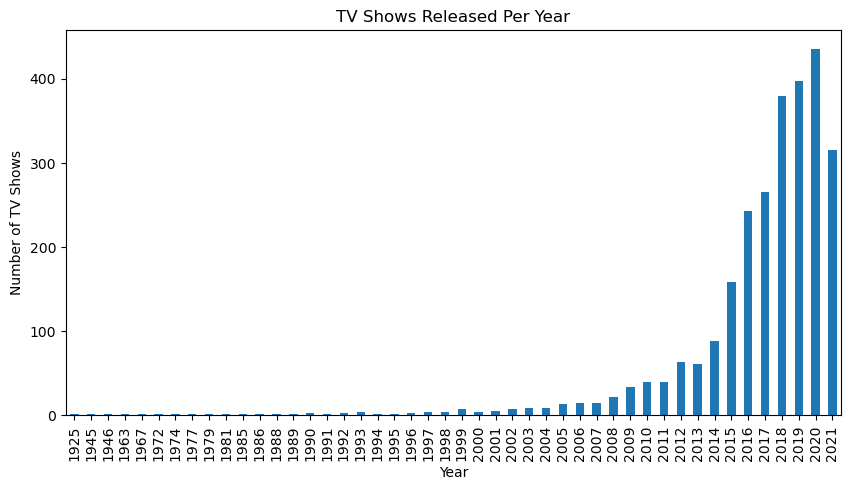

In [15]:
#How many shows were released each year?
tv_shows_per_year = df[df['type'] == 'TV Show'].groupby('release_year').size()
tv_shows_per_year.plot(kind='bar', figsize=(10,5))
plt.title("TV Shows Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of TV Shows")
plt.show()

In [26]:
#Which year produced the most content?
df.groupby('release_year').size().sort_values(ascending=False).head(1)

release_year
2018    1146
dtype: int64

## Country Analysis

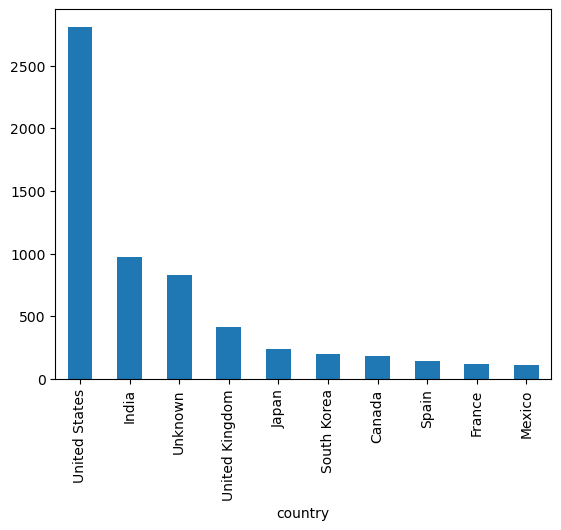

In [30]:
#Which countries produce the most Netflix content?
df.groupby('country').size().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

## Genre Analysis

In [43]:
#Top 10 genres
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [44]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## Movie Duration Analysis

In [51]:
#Average movie duration
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

In [52]:
movies['duration_num'].mean()

np.float64(99.58488410055502)

In [53]:
movies['duration_num'].max()

312

In [54]:
movies['duration_num'].min()

3

(array([1.470e+02, 4.490e+02, 2.095e+03, 2.568e+03, 6.920e+02, 1.440e+02,
        2.200e+01, 6.000e+00, 2.000e+00, 1.000e+00]),
 array([  3. ,  33.9,  64.8,  95.7, 126.6, 157.5, 188.4, 219.3, 250.2,
        281.1, 312. ]),
 <BarContainer object of 10 artists>)

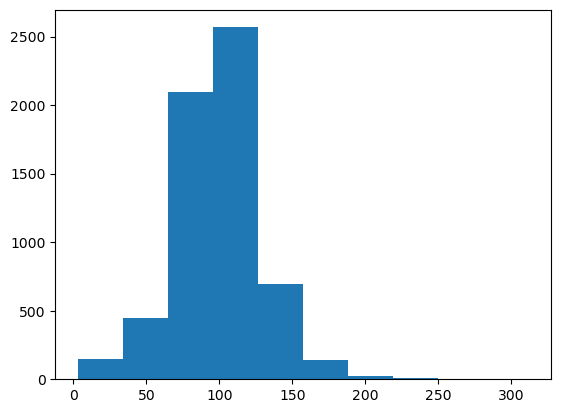

In [60]:
plt.hist(x=movies['duration_num'])

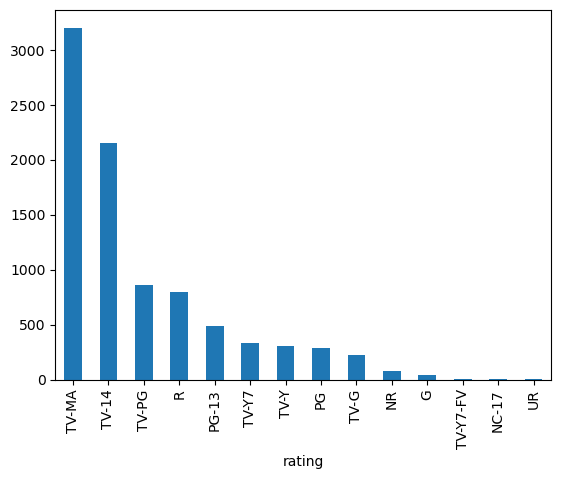

In [68]:
df['rating'].value_counts().plot(kind='bar')
plt.show()

<Axes: xlabel='date_added'>

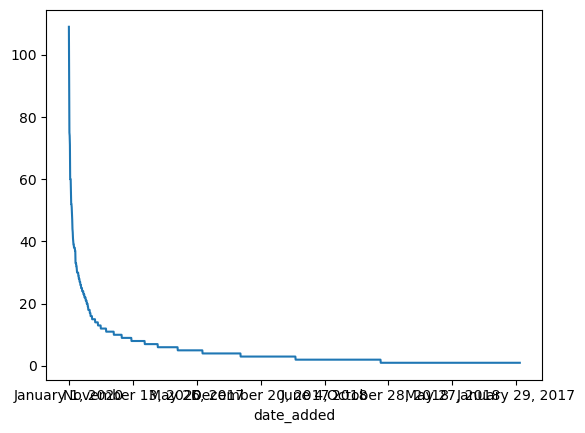

In [69]:
# shows added each year

df['date_added'].value_counts().plot(kind='line')
